# IBM HR Employee Attrition Analysis

This notebook explores IBM HR employee attrition through data preparation, exploratory analysis, and predictive modeling. The models identify patterns in this dataset; their risk scores are exploratory and should not be treated as causal findings or employment decisions.

## 1. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Load and Prepare Data

In [ ]:
df = pd.read_csv("Dataset/IBM HR Analytics Employee Attrition & Performance.csv")
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


### Data Checks and Preparation

In [ ]:
# Row & Columns
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}\n")
# Check Duplication
duplicate_count = df.duplicated().sum()
print(f"Duplicate Rows: {duplicate_count:,}\n")
# Columns data-types
df.dtypes

Rows: 1,470
Columns: 35

Duplicate Rows: 0



Age                         int64
Attrition                     str
BusinessTravel                str
DailyRate                   int64
Department                    str
DistanceFromHome            int64
Education                   int64
EducationField                str
EmployeeCount               int64
EmployeeNumber              int64
EnvironmentSatisfaction     int64
Gender                        str
HourlyRate                  int64
JobInvolvement              int64
JobLevel                    int64
JobRole                       str
JobSatisfaction             int64
MaritalStatus                 str
MonthlyIncome               int64
MonthlyRate                 int64
NumCompaniesWorked          int64
Over18                        str
OverTime                      str
PercentSalaryHike           int64
PerformanceRating           int64
RelationshipSatisfaction    int64
StandardHours               int64
StockOptionLevel            int64
TotalWorkingYears           int64
TrainingTimesL

In [ ]:
# Check missing value
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Column Drop & Reason
- `EmployeeCount`, `Over18`, `StandardHours`: Same value in every row (1, "Y", 80), so they carry no information.
- `EmployeeNumber`: Unique ID. Used as the index, not as a feature.
- `DailyRate`, `HourlyRate`, `MonthlyRate`: Correlation with MonthlyIncome is near zero (see check below) and attrition does not vary across their quartiles. MonthlyIncome is kept as the pay measure.

see below...

In [ ]:
raw = pd.read_csv("Dataset/IBM HR Analytics Employee Attrition & Performance.csv")
raw["Attrition"] = raw["Attrition"].map({"Yes": 1, "No": 0})

rate_cols = ["DailyRate", "HourlyRate", "MonthlyRate"]
labels = ["Q1 (low)", "Q2", "Q3", "Q4 (high)"]

summary = []
for c in rate_cols:
    q = pd.qcut(raw[c], 4, labels=labels)
    rates = (raw.groupby(q, observed=True)["Attrition"].mean() * 100).round(1)
    summary.append({"Column": c,
                    "Corr with MonthlyIncome": round(raw[c].corr(raw["MonthlyIncome"]), 3),
                    **rates.to_dict(),
                    "Spread (pts)": round(rates.max() - rates.min(), 1)})
display(pd.DataFrame(summary))

,Column,Corr with MonthlyIncome,Q1 (low),Q2,Q3,Q4 (high),Spread (pts)
0,DailyRate,0.008,20.1,16.1,15.3,13.1,7.0
1,HourlyRate,-0.016,15.2,18.0,14.6,16.6,3.4
2,MonthlyRate,0.035,14.4,16.6,15.5,17.9,3.5


In [ ]:
# Column Drop
df = df[['EmployeeNumber', 'Age', 'Gender', 'MaritalStatus',
         'Education', 'EducationField', 'DistanceFromHome', 'Department',
         'JobRole', 'JobLevel', 'MonthlyIncome', 'PercentSalaryHike',
         'StockOptionLevel', 'BusinessTravel', 'OverTime',
         'NumCompaniesWorked', 'TotalWorkingYears', 'YearsAtCompany',
         'YearsInCurrentRole', 'YearsSinceLastPromotion',
         'YearsWithCurrManager', 'PerformanceRating',
         'TrainingTimesLastYear', 'EnvironmentSatisfaction',
         'JobInvolvement', 'JobSatisfaction',
         'RelationshipSatisfaction', 'WorkLifeBalance', 'Attrition']
        ].set_index('EmployeeNumber')


In [ ]:
# Row & Columns
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}\n")

Rows: 1,470
Columns: 28



In [ ]:
# Encoding
df['Attrition']= df['Attrition'].map({'Yes':1,'No':0})

In [ ]:
df.head()

,Age,Gender,MaritalStatus,Education,EducationField,DistanceFromHome,Department,JobRole,JobLevel,MonthlyIncome,...,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating,TrainingTimesLastYear,EnvironmentSatisfaction,JobInvolvement,JobSatisfaction,RelationshipSatisfaction,WorkLifeBalance,Attrition
EmployeeNumber,,,,,,,,,,,,,,,,,,,,,
1,41,Female,Single,2,Life Sciences,1,Sales,Sales Executive,2,5993,...,0,5,3,0,2,3,4,1,1,1
2,49,Male,Married,1,Life Sciences,8,Research & Development,Research Scientist,2,5130,...,1,7,4,3,3,2,2,4,3,0
4,37,Male,Single,2,Other,2,Research & Development,Laboratory Technician,1,2090,...,0,0,3,3,4,2,3,2,3,1
5,33,Female,Married,4,Life Sciences,3,Research & Development,Research Scientist,1,2909,...,3,0,3,3,4,3,3,3,3,0
7,27,Male,Married,1,Medical,2,Research & Development,Laboratory Technician,1,3468,...,2,2,3,3,1,3,2,4,3,0


In [ ]:
df.tail()

,Age,Gender,MaritalStatus,Education,EducationField,DistanceFromHome,Department,JobRole,JobLevel,MonthlyIncome,...,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating,TrainingTimesLastYear,EnvironmentSatisfaction,JobInvolvement,JobSatisfaction,RelationshipSatisfaction,WorkLifeBalance,Attrition
EmployeeNumber,,,,,,,,,,,,,,,,,,,,,
2061,36,Male,Married,2,Medical,23,Research & Development,Laboratory Technician,2,2571,...,0,3,3,3,3,4,4,3,3,0
2062,39,Male,Married,1,Medical,6,Research & Development,Healthcare Representative,3,9991,...,1,7,3,5,4,2,1,1,3,0
2064,27,Male,Married,3,Life Sciences,4,Research & Development,Manufacturing Director,2,6142,...,0,3,4,0,2,4,2,2,3,0
2065,49,Male,Married,3,Medical,2,Sales,Sales Executive,2,5390,...,0,8,3,3,4,2,2,4,2,0
2068,34,Male,Married,3,Medical,8,Research & Development,Laboratory Technician,2,4404,...,1,2,3,3,2,4,3,1,4,0


In [ ]:
from pathlib import Path
import shutil

dataset_path = Path("Dataset/IBM HR Analytics Employee Attrition & Performance.csv")
backup_path = dataset_path.with_name(dataset_path.stem + "_backup.csv")

if not dataset_path.exists():
    raise FileNotFoundError(f"Dataset not found: {dataset_path}")

shutil.copy2(dataset_path, backup_path)
df.to_csv(dataset_path, index=True, index_label="EmployeeNumber")

print(f"Replaced: {dataset_path}")
print(f"Original backed up to: {backup_path}")

## 3. Exploratory Data Analysis

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.0,36.0,43.0,60.0
Education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.0,2.0,3.0,5.0
MonthlyIncome,1470.0,6502.931293,4707.956783,1009.0,2911.0,4919.0,8379.0,19999.0
PercentSalaryHike,1470.0,15.209524,3.659938,11.0,12.0,14.0,18.0,25.0
StockOptionLevel,1470.0,0.793878,0.852077,0.0,0.0,1.0,1.0,3.0
NumCompaniesWorked,1470.0,2.693197,2.498009,0.0,1.0,2.0,4.0,9.0
TotalWorkingYears,1470.0,11.279592,7.780782,0.0,6.0,10.0,15.0,40.0
YearsAtCompany,1470.0,7.008163,6.126525,0.0,3.0,5.0,9.0,40.0


### Survey Ratings

In [ ]:
survey_columns = [
    "EnvironmentSatisfaction",
    "JobInvolvement",
    "JobSatisfaction",
    "RelationshipSatisfaction",
    "WorkLifeBalance"
]

survey_summary = (
    df[survey_columns]
    .mean()
    .sort_values(ascending=False)
    .to_frame("Mean Rating")
    .round(2)
)

# Interpret the mean rating
def interpret_rating(mean):
    if mean <= 1.75:
        return "Very Low / Very Negative"
    elif mean <= 2.50:
        return "Low / Negative"
    elif mean <= 3.25:
        return "Moderate / Neutral"
    else:
        return "High / Positive"

survey_summary["Interpretation"] = survey_summary["Mean Rating"].apply(interpret_rating)
print("n sample", df.shape[0])
display(survey_summary)

n sample 1470


,Mean Rating,Interpretation
WorkLifeBalance,2.76,Moderate / Neutral
JobInvolvement,2.73,Moderate / Neutral
JobSatisfaction,2.73,Moderate / Neutral
EnvironmentSatisfaction,2.72,Moderate / Neutral
RelationshipSatisfaction,2.71,Moderate / Neutral


### Overall Attrition

In [ ]:
total_employee_count = len(df)
attrition_count = df["Attrition"].sum()
attrition_rate = attrition_count / total_employee_count * 100

summary = pd.DataFrame({
    "Metric": ["Total Employees", "Attrition Count", "Attrition Rate"],
    "Value": [
        total_employee_count,
        attrition_count,
        f"{attrition_rate:.2f}%"
    ]
})

summary

,Metric,Value
0,Total Employees,1470
1,Attrition Count,237
2,Attrition Rate,16.12%


### Attrition Rate Analysis

#### Correlation

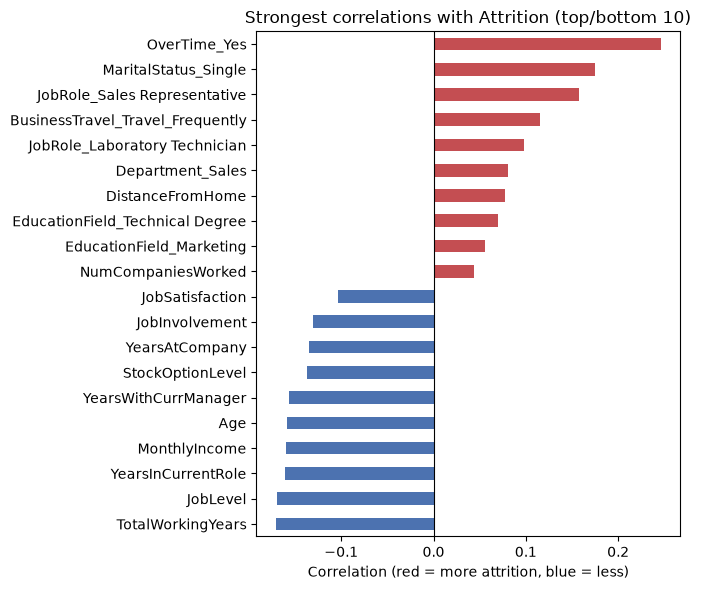

In [ ]:
encoded = pd.get_dummies(df.drop(columns="Attrition"), drop_first=True, dtype=int)
corr = encoded.corrwith(df["Attrition"]).dropna().sort_values()
top = pd.concat([corr.head(10), corr.tail(10)])

plt.figure(figsize=(7, 6))
top.plot(kind="barh", color=["#4C72B0" if v < 0 else "#C44E52" for v in top])
plt.axvline(0, color="black", lw=0.8)
plt.title("Strongest correlations with Attrition (top/bottom 10)")
plt.xlabel("Correlation (red = more attrition, blue = less)")
plt.tight_layout()
plt.show()

#### Screening
- Screen every columns to detect which columns worth attention
- by how spread the data was

In [ ]:
# Screen every Column
cols = [c for c in df.columns if c != "Attrition"]
rows = []
for c in cols:
    s = df[c]
    # bin numeric columns with many unique values
    if s.dtype.kind in "if" and s.nunique() > 10:
        s = pd.qcut(s, 4, duplicates="drop")
    g = df.groupby(s, observed=True)["Attrition"].agg(["count", "mean"])
    g = g[g["count"] >= 30]            # ignore tiny groups
    rows.append({"Column": c,
                 "Lowest %": round(g["mean"].min() * 100, 1),
                 "Highest %": round(g["mean"].max() * 100, 1),
                 "Spread (pts)": round((g["mean"].max() - g["mean"].min()) * 100, 1)})

screen = pd.DataFrame(rows).sort_values("Spread (pts)", ascending=False)
screen.index = pd.RangeIndex(1, len(screen) + 1, name="Rank")
screen

,Column,Lowest %,Highest %,Spread (pts)
Rank,,,,
1,JobRole,2.5,39.8,37.3
2,JobInvolvement,9.0,33.7,24.7
3,JobLevel,4.7,26.3,21.6
4,OverTime,10.4,30.5,20.1
5,MonthlyIncome,10.3,29.3,18.9
6,TrainingTimesLastYear,9.2,27.8,18.5
7,Age,8.9,25.9,17.0
8,WorkLifeBalance,14.2,31.2,17.0
9,BusinessTravel,8.0,24.9,16.9


#### Analyzing Important Fields

In [ ]:
# reusable attrition analysis function
def attrition_by(col, data=df, sort=True):
    out = (
        data.groupby(col, observed=True)["Attrition"]
            .agg(Headcount="count", Leavers="sum", Rate="mean")
            .assign(Rate=lambda t: (t["Rate"] * 100).round(1))
            .rename(columns={"Rate": "Attrition Rate (%)"})
    )
    if sort:
        out = out.sort_values("Attrition Rate (%)", ascending=False)
    return out.reset_index()

# Bin separate
df["TenureBand"] = pd.cut(df["YearsAtCompany"],
                          bins=[-1, 2, 5, 10, 50],
                          labels=["0-2", "3-5", "6-10", "10+"])

df["IncomeBand"] = pd.qcut(df["MonthlyIncome"], 4,
                           labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])

# Decoding
job_involvement = attrition_by("JobInvolvement")
job_involvement["JobInvolvement"] = job_involvement["JobInvolvement"].map({
    1: "Low",
    2: "Medium",
    3: "High",
    4: "Very High"
})

# Top 5 Screening
display(
    attrition_by("JobRole"),
    job_involvement,
    attrition_by("TenureBand", sort=False),
    attrition_by("JobLevel", sort=False),
    attrition_by("OverTime"),
    attrition_by("IncomeBand", sort=False)
)

,JobRole,Headcount,Leavers,Attrition Rate (%)
0,Sales Representative,83,33,39.8
1,Laboratory Technician,259,62,23.9
2,Human Resources,52,12,23.1
3,Sales Executive,326,57,17.5
4,Research Scientist,292,47,16.1
5,Healthcare Representative,131,9,6.9
6,Manufacturing Director,145,10,6.9
7,Manager,102,5,4.9
8,Research Director,80,2,2.5


,JobInvolvement,Headcount,Leavers,Attrition Rate (%)
0,Low,83,28,33.7
1,Medium,375,71,18.9
2,High,868,125,14.4
3,Very High,144,13,9.0


,TenureBand,Headcount,Leavers,Attrition Rate (%)
0,0-2,342,102,29.8
1,3-5,434,60,13.8
2,6-10,448,55,12.3
3,10+,246,20,8.1


,JobLevel,Headcount,Leavers,Attrition Rate (%)
0,1,543,143,26.3
1,2,534,52,9.7
2,3,218,32,14.7
3,4,106,5,4.7
4,5,69,5,7.2


,OverTime,Headcount,Leavers,Attrition Rate (%)
0,Yes,416,127,30.5
1,No,1054,110,10.4


,IncomeBand,Headcount,Leavers,Attrition Rate (%)
0,Q1 (lowest),369,108,29.3
1,Q2,366,52,14.2
2,Q3,367,39,10.6
3,Q4 (highest),368,38,10.3


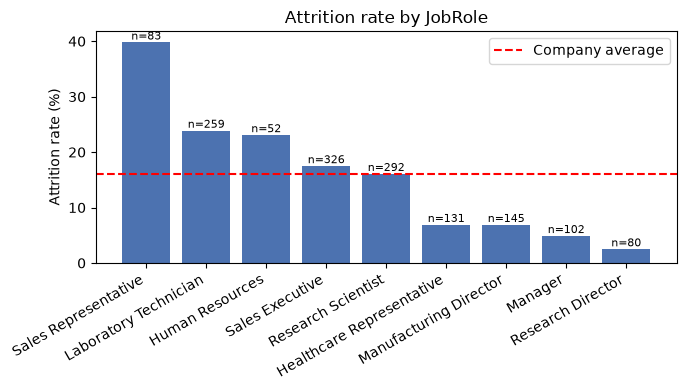

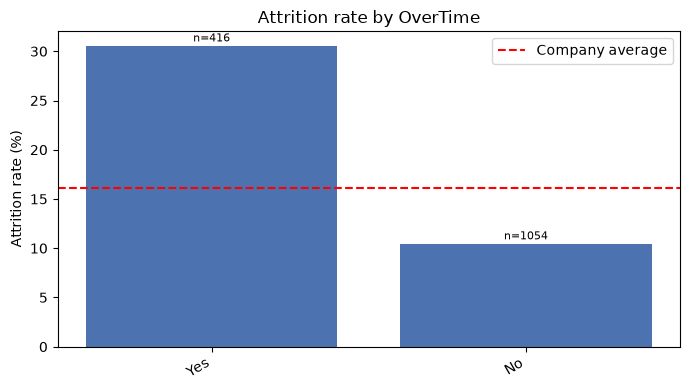

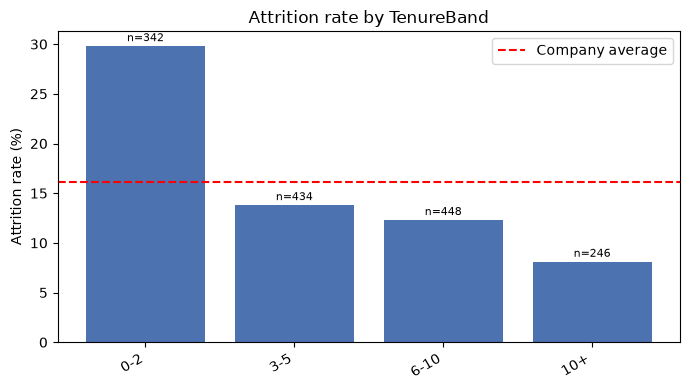

In [ ]:
def plot_attrition(col, data=df, order=None):
    t = attrition_by(col, data, sort=(order is None))
    if order:
        t = t.set_index(col).loc[order].reset_index()

    fig, ax = plt.subplots(figsize=(7, 4))
    bars = ax.bar(t[col].astype(str), t["Attrition Rate (%)"], color="#4C72B0")
    ax.axhline(data["Attrition"].mean() * 100, color="red", ls="--", label="Company average")

    for b, n in zip(bars, t["Headcount"]):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5,
                f"n={n}", ha="center", fontsize=8)

    ax.set_ylabel("Attrition rate (%)")
    ax.set_title(f"Attrition rate by {col}")
    ax.legend()
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
plot_attrition("JobRole")
plot_attrition("OverTime")
plot_attrition("TenureBand", order=["0-2", "3-5", "6-10", "10+"])

## 4. Logistic Regression

In [ ]:
from sklearn.model_selection import (train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
                                     cross_validate, cross_val_predict, GridSearchCV)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay, RocCurveDisplay,
                             PrecisionRecallDisplay, roc_auc_score, average_precision_score)

RANDOM_STATE = 42

### 1. Define features (and guard against leakage)
Bands created for EDA duplicate the raw columns they came from, so they must not enter the model.

In [ ]:
helper_cols = [c for c in ["TenureBand", "IncomeBand"] if c in df.columns]
X = df.drop(columns=["Attrition"] + helper_cols)
y = df["Attrition"]

assert set(y.unique()) <= {0, 1}, "Attrition must be coded 1/0 before modelling"
assert X.isna().sum().sum() == 0, "Missing values found: handle them before modelling"

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print(f"Employees: {len(X)} | Leavers: {y.sum()} ({y.mean():.1%})")
print(f"{len(numeric_features)} numeric + {len(categorical_features)} categorical features")
print("Removed helper columns:", helper_cols or "none")

Employees: 1470 | Leavers: 237 (16.1%)
20 numeric + 7 categorical features
Removed helper columns: ['TenureBand', 'IncomeBand']


### 2. Model builder
* `drop="if_binary"`: OverTime / Gender become ONE column each (e.g. `OverTime_Yes`), easier to read.
* Categories are fixed from the full data, so every bootstrap/CV fit has identical columns.
* `class_weight="balanced"` makes the model take the 16% leavers seriously. Side effect: the output is a **risk score**, not a true probability.

In [ ]:
def make_model(C=1.0):
    pre = ColumnTransformer([
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore",
                              categories=[sorted(X[c].unique()) for c in categorical_features]),
         categorical_features),
    ])
    return Pipeline([
        ("prep", pre),
        ("clf", LogisticRegression(C=C, class_weight="balanced", max_iter=2000,
                                   random_state=RANDOM_STATE)),
    ])

### 3. Cross-validation: how stable is the model?
5 folds x 3 repeats = 15 mini-exams. Look at the **std**: small means results are stable.

In [ ]:
rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
cv_scores = cross_validate(
    make_model(), X, y, cv=rcv,
    scoring={"roc_auc": "roc_auc", "recall": "recall",
             "precision": "precision", "avg_precision": "average_precision"},
)
cv_summary = (pd.DataFrame(cv_scores).filter(like="test_")
              .rename(columns=lambda c: c.replace("test_", ""))
              .agg(["mean", "std"]).T.round(3))
print(f"Baseline for reference: random guessing gives precision ≈ {y.mean():.2f} and ROC-AUC = 0.50")
cv_summary

Baseline for reference: random guessing gives precision ≈ 0.16 and ROC-AUC = 0.50


,mean,std
roc_auc,0.827,0.029
recall,0.733,0.042
precision,0.370,0.029
avg_precision,0.589,0.049


### 4. Train/test split + tuning the regularisation strength `C`
`C` controls how much the model is discouraged from overfitting (smaller = simpler).
Tuning uses **only the training data**. The test set stays untouched until the final check.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(make_model(), {"clf__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10]},
                    scoring="roc_auc", cv=cv5)
grid.fit(X_train, y_train)

best_C = grid.best_params_["clf__C"]
model = grid.best_estimator_
print(f"Best C = {best_C} (cross-validated ROC-AUC on training data: {grid.best_score_:.3f})")

Best C = 0.1 (cross-validated ROC-AUC on training data: 0.832)


### 5. Final check on the held-out test set

              precision    recall  f1-score   support

      Stayed       0.93      0.79      0.86       247
        Left       0.39      0.70      0.50        47

    accuracy                           0.78       294
   macro avg       0.66      0.75      0.68       294
weighted avg       0.85      0.78      0.80       294

ROC-AUC: 0.821  |  Average precision: 0.597 (random ≈ 0.16)


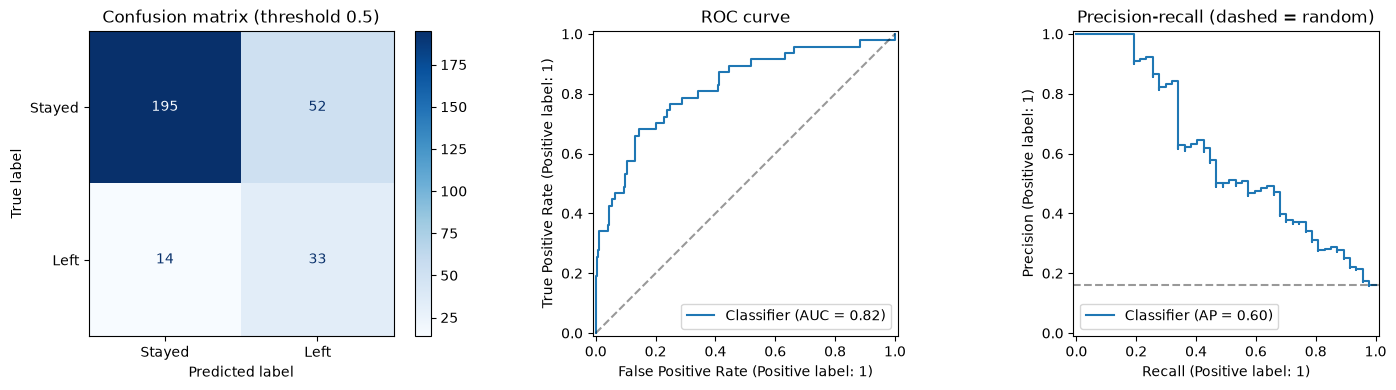

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print(classification_report(y_test, y_pred, target_names=["Stayed", "Left"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}  |  "
      f"Average precision: {average_precision_score(y_test, y_prob):.3f} "
      f"(random ≈ {y_test.mean():.2f})")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["Stayed", "Left"],
                                        cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion matrix (threshold 0.5)")
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1])
axes[1].plot([0, 1], [0, 1], "k--", alpha=.4)
axes[1].set_title("ROC curve")
PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[2])
axes[2].axhline(y_test.mean(), color="k", ls="--", alpha=.4)
axes[2].set_title("Precision-recall (dashed = random)")
plt.tight_layout()
plt.show()

### 6. Choosing how many people to flag
The default 0.5 cut-off is arbitrary. Pick based on HR capacity:
* **Threshold table**: stricter cut-off means fewer false alarms but more leavers missed.
* **Top X% table**: "if we can only talk to the riskiest 10/20/30%, how many leavers do we reach?" Lift above 1.0 beats random.

In [ ]:
y_arr = y_test.to_numpy()
rows = []
for t in np.arange(0.30, 0.85, 0.05):
    flagged = y_prob >= t
    tp = int((flagged & (y_arr == 1)).sum())
    rows.append({"Threshold": round(t, 2), "Flagged": int(flagged.sum()),
                 "Leavers caught": tp, "Recall": round(tp / y_arr.sum(), 2),
                 "Precision": round(tp / max(flagged.sum(), 1), 2)})
threshold_table = pd.DataFrame(rows)
display(threshold_table)

order = np.argsort(-y_prob)
rows = []
for pct in (10, 20, 30, 40):
    k = int(len(y_arr) * pct / 100)
    caught = int(y_arr[order[:k]].sum())
    rows.append({"Top % flagged": pct, "People": k, "Leavers caught": caught,
                 "Share of all leavers": round(caught / y_arr.sum(), 2),
                 "Lift vs random": round((caught / y_arr.sum()) / (pct / 100), 2)})
capacity_table = pd.DataFrame(rows)
display(capacity_table)

,Threshold,Flagged,Leavers caught,Recall,Precision
0,0.30,152,42,0.89,0.28
1,0.35,137,38,0.81,0.28
2,0.40,118,37,0.79,0.31
3,0.45,98,36,0.77,0.37
4,0.50,85,33,0.70,0.39
5,0.55,73,32,0.68,0.44
6,0.60,54,27,0.57,0.50
7,0.65,45,22,0.47,0.49
8,0.70,35,21,0.45,0.60
9,0.75,29,18,0.38,0.62


,Top % flagged,People,Leavers caught,Share of all leavers,Lift vs random
0,10,29,18,0.38,3.83
1,20,58,27,0.57,2.87
2,30,88,33,0.70,2.34
3,40,117,37,0.79,1.97


### 7. Drivers: what pushes attrition up or down?
This is the main output for an HR manager. The model is refit on **all** employees (we are explaining, not testing), and the bootstrap resamples employees 200 times to see if each effect is stable.

**How to read the odds ratio (OR):**
* OR = 1.0: no effect. OR = 2.0: odds of leaving roughly double. OR = 0.5: roughly halve.
* Numeric features are standardised, so OR is **per +1 standard deviation**.
* `OverTime_Yes` compares Yes vs No. `JobRole_X` compares that role vs the average of the others.
* **Stable = Yes** means the 95% range does not cross 1.0. Treat "No" rows as unproven.
* Age, JobLevel, MonthlyIncome and tenure overlap heavily, so their individual ORs can be shaky. Don't over-read them.

In [ ]:
final = make_model(best_C).fit(X, y)
feature_names = [n.split("__", 1)[1] for n in final.named_steps["prep"].get_feature_names_out()]
coef = final.named_steps["clf"].coef_[0]

rng = np.random.default_rng(RANDOM_STATE)
boot = np.empty((200, len(coef)))
for i in range(200):
    idx = rng.integers(0, len(X), len(X))
    boot[i] = make_model(best_C).fit(X.iloc[idx], y.iloc[idx]).named_steps["clf"].coef_[0]
lo, hi = np.percentile(boot, [2.5, 97.5], axis=0)

drivers = pd.DataFrame({
    "Feature": feature_names,
    "Odds ratio": np.exp(coef),
    "CI low": np.exp(lo),
    "CI high": np.exp(hi),
})
drivers["Stable?"] = np.where((drivers["CI low"] > 1) | (drivers["CI high"] < 1), "Yes", "No")
drivers["_size"] = np.abs(coef)
drivers = drivers.sort_values("_size", ascending=False).drop(columns="_size").reset_index(drop=True)
drivers.round(2).head(15)

,Feature,Odds ratio,CI low,CI high,Stable?
0,OverTime_Yes,3.92,3.23,5.43,Yes
1,BusinessTravel_Non-Travel,0.54,0.42,0.68,Yes
2,BusinessTravel_Travel_Frequently,1.83,1.46,2.28,Yes
3,MaritalStatus_Single,1.65,1.33,2.21,Yes
4,YearsAtCompany,1.64,1.06,2.36,Yes
5,JobRole_Laboratory Technician,1.63,1.23,2.10,Yes
6,YearsSinceLastPromotion,1.58,1.26,2.11,Yes
7,EducationField_Technical Degree,1.58,1.13,2.14,Yes
8,MaritalStatus_Divorced,0.65,0.51,0.84,Yes
9,YearsWithCurrManager,0.65,0.50,0.86,Yes


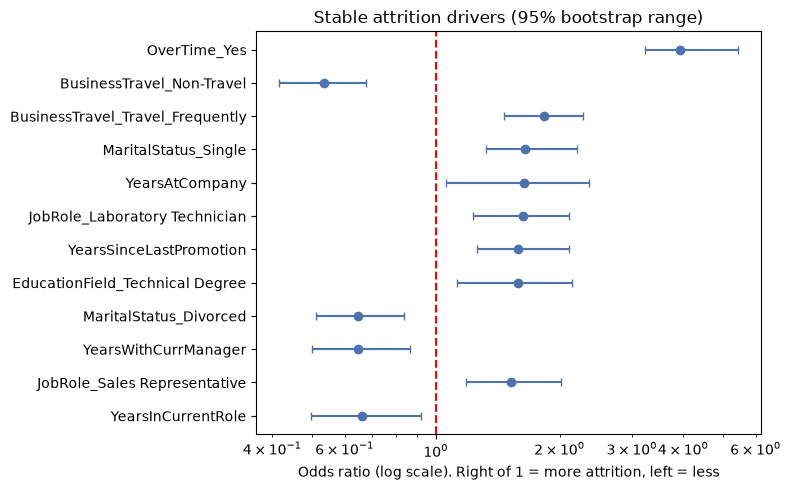

In [ ]:
top = drivers[drivers["Stable?"] == "Yes"].head(12).iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(top["Odds ratio"], range(len(top)),
            xerr=[top["Odds ratio"] - top["CI low"], top["CI high"] - top["Odds ratio"]],
            fmt="o", color="#4C72B0", capsize=3)
ax.axvline(1, color="red", ls="--")
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top["Feature"])
ax.set_xscale("log")
ax.set_xlabel("Odds ratio (log scale). Right of 1 = more attrition, left = less")
ax.set_title("Stable attrition drivers (95% bootstrap range)")
plt.tight_layout()
plt.show()

### 8. Risk by segment (replaces the individual top-20 list)
Each employee's score comes from a model that **never saw that employee**, using out-of-fold predictions. Scores are averaged by group.
Compare the *ranking* of segments. The average score runs higher than the real rate because of `class_weight="balanced"`.

In [ ]:
oof = cross_val_predict(make_model(best_C), X, y, cv=cv5, method="predict_proba")[:, 1]
print(f"Out-of-fold ROC-AUC: {roc_auc_score(y, oof):.3f}")

seg = X.assign(risk_score=oof, left=y)
seg["TenureBand"] = pd.cut(seg["YearsAtCompany"], [-1, 2, 5, 10, 50],
                           labels=["0-2", "3-5", "6-10", "10+"])

def segment_risk(col, min_n=30):
    t = (seg.groupby(col, observed=True)
            .agg(Headcount=("left", "size"),
                 Avg_risk_score=("risk_score", "mean"),
                 Actual_attrition=("left", "mean"))
            .query("Headcount >= @min_n")
            .sort_values("Avg_risk_score", ascending=False))
    t["Avg_risk_score"] = (t["Avg_risk_score"] * 100).round(1)
    t["Actual_attrition"] = (t["Actual_attrition"] * 100).round(1)
    return t.rename(columns={"Avg_risk_score": "Avg risk score", "Actual_attrition": "Actual attrition %"})

for col in ["OverTime", "JobRole", "MaritalStatus", "TenureBand"]:
    print(f"\n--- {col} ---")
    display(segment_risk(col))

Out-of-fold ROC-AUC: 0.830

--- OverTime ---


,Headcount,Avg risk score,Actual attrition %
OverTime,,,
Yes,416,53.7,30.5
No,1054,31.3,10.4



--- JobRole ---


,Headcount,Avg risk score,Actual attrition %
JobRole,,,
Sales Representative,83,65.8,39.8
Laboratory Technician,259,47.9,23.9
Human Resources,52,46.5,23.1
Sales Executive,326,40.8,17.5
Research Scientist,292,38.5,16.1
Healthcare Representative,131,26.7,6.9
Manufacturing Director,145,25.6,6.9
Manager,102,19.5,4.9
Research Director,80,16.1,2.5



--- MaritalStatus ---


,Headcount,Avg risk score,Actual attrition %
MaritalStatus,,,
Single,470,49.2,25.5
Married,673,34.3,12.5
Divorced,327,27.8,10.1



--- TenureBand ---


,Headcount,Avg risk score,Actual attrition %
TenureBand,,,
0-2,342,49.4,29.8
3-5,434,41.0,13.8
6-10,448,31.5,12.3
10+,246,26.5,8.1


## 5. Conclusion

Overall. 237 of 1,470 employees left (16.1%). Attrition is concentrated, not spread evenly.

Where attrition is highest

- `Overtime`: 30.5% vs 10.4%. Only 28% of employees work overtime, yet they are 54% of leavers (127 of 237). It is also the strongest model driver (odds ratio ≈ 3.9, 95% range 3.2 to 5.4).
- `Early tenure`: employees with 0-2 years leave at 29.8% (vs 8.1% at 10+ years). This group is 23% of staff and 43% of leavers.
- `Roles`: Sales Representative (39.8%, n=83) and Laboratory Technician (23.9%, n=259). Together they are 23% of staff and 40% of leavers. HR (23.1%, n=52) has too few people to draw firm conclusions.
- `Entry level and low pay`: Level 1 employees leave at 26.3%, and the lowest income quartile at 29.3%. These overlap with early tenure and role, so they are not separate causes.
- Frequent business travel (odds ratio ≈ 1.8) and low job involvement (33.7% vs 9.0%) also stand out.

**What did not matter**: performance rating, gender, salary hike %, department and distance from home show little relationship with attrition.

**Model**. Logistic regression separates leavers from stayers well (cross-validated ROC-AUC 0.83 ± 0.03, consistent on the test set). Flagging the riskiest 20% of employees reaches 57% of leavers, 2.9 times better than random. The tool suits prioritising groups, not deciding on individuals.

### Recommended actions

1. Review overtime workload and staffing in high-overtime teams, and track attrition after any change.
2. Strengthen onboarding and early-career support for employees in their first 2 years.
3. Investigate why Sales Representative and Laboratory Technician roles lose so many people (pay, workload, progression).
4. Check progression for long-serving employees who haven't been promoted.
5. Follow up on frequent-travel roles and low-involvement teams.

**Limits**. Single snapshot with no time dimension. Findings are associations, not causes. Several variables overlap, so individual effects can be shaky. Age and marital status describe who leaves but should not be used in employment decisions. The dataset is generally regarded as fictional.